**Physics-Informed Neural Network (PINN) implementation for the DC motor control system**

This notebook follows `control_systems.ipynb`: it simulates the same two-state DC motor model with the same candidate library used by the WyNDA observer. Instead of the adaptive observer update, a PINN learns the state trajectory and the library coefficients by combining sparse measurement loss with the differential-equation residual.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


**Simulate the control system**

In [2]:
# time horizon
TF = 1.0
DT = 0.0005
t = np.arange(0.0, TF + DT, DT)

# true parameters
J = 0.01
b = 0.1
K = 0.2
R = 1.0
L = 0.5

# measurement noise; keep the same dt-scaled form as the original code
RF = 1.0

# simulate by explicit Euler, matching the original notebook
x = np.array([1.0, 1.0], dtype=np.float64)
x_array = []
y_array = []
u_array = []

for tk in t:
    u = 4.0 * np.sin(40.0 * tk)
    x_array.append(x.copy())
    y_array.append(x + DT * (RF**2) * np.random.randn(2))
    u_array.append(u)

    A = np.array([
        [-b / J, K / J],
        [-K / L, -R / L],
    ])
    B = np.array([0.0, 1.0 / L])
    x = x + DT * ((A @ x) + B * u)

x_array = np.asarray(x_array)
y_array = np.asarray(y_array)
u_array = np.asarray(u_array)[:, None]

true_coeff = np.zeros((2, 7))
true_coeff[0, 0] = -b / J
true_coeff[0, 1] = K / J
true_coeff[1, 0] = -K / L
true_coeff[1, 1] = -R / L
true_coeff[1, 5] = 1.0 / L

print(f'Simulated {len(t)} time samples')
print('True coefficient matrix:')
print(true_coeff)


Simulated 2001 time samples
True coefficient matrix:
[[-10.   20.    0.    0.    0.    0.    0. ]
 [ -0.4  -2.    0.    0.    0.    2.    0. ]]


**Prepare PINN training points**

The PINN sees sparse measured data but enforces the physics residual across the full simulated horizon. Time is normalized to \([-1,1]\), which usually makes the neural network optimization less fussy.


In [3]:
def scale_time(t_np):
    return 2.0 * (t_np / TF) - 1.0

# sparse data points for state fitting
data_stride = 20
data_idx = np.arange(0, len(t), data_stride)

# all points are used for the physics residual
collocation_idx = np.arange(len(t))

t_train = torch.tensor(scale_time(t[data_idx, None]), dtype=torch.float32, device=device)
y_train = torch.tensor(y_array[data_idx], dtype=torch.float32, device=device)

t_phys = torch.tensor(
    scale_time(t[collocation_idx, None]),
    dtype=torch.float32,
    device=device,
    requires_grad=True,
)
t_all = torch.tensor(scale_time(t[:, None]), dtype=torch.float32, device=device)

y_mean = torch.tensor(y_array[data_idx].mean(axis=0), dtype=torch.float32, device=device)
y_std = torch.tensor(y_array[data_idx].std(axis=0), dtype=torch.float32, device=device)


def control_from_scaled_time(t_scaled):
    t_seconds = 0.5 * TF * (t_scaled + 1.0)
    return 4.0 * torch.sin(40.0 * t_seconds)


**Define the PINN**

The network outputs the two states \(omega\) and \(i\). A trainable coefficient matrix multiplies the same seven-feature library for each state equation, giving fourteen candidate coefficients in the same layout as `control_systems.ipynb`.


In [4]:
class MLP(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 2)]
        self.net = nn.Sequential(*layers)

    def forward(self, t_scaled):
        # Predict normalized states, then map back to physical units.
        return self.net(t_scaled) * y_std + y_mean


def library_features(x_pred, u):
    omega = x_pred[:, 0:1]
    current = x_pred[:, 1:2]
    return torch.cat([
        omega,
        current,
        omega**2,
        current**2,
        omega * current,
        u,
        u**2,
    ], dim=1)


class ControlSystemPINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        self.state_net = MLP(width=width, depth=depth)
        self.theta = nn.Parameter(0.01 * torch.randn(2, 7))

    def forward(self, t_scaled):
        return self.state_net(t_scaled)

    def residual(self, t_scaled):
        x_pred = self.forward(t_scaled)
        u = control_from_scaled_time(t_scaled)
        phi = library_features(x_pred, u)
        rhs = phi @ self.theta.T

        dx_dt_scaled = []
        for state_col in range(2):
            grad = torch.autograd.grad(
                x_pred[:, state_col].sum(),
                t_scaled,
                create_graph=True,
            )[0]
            dx_dt_scaled.append(grad)
        dx_dt_scaled = torch.cat(dx_dt_scaled, dim=1)

        # t_scaled = 2*t/TF - 1, so dx/dt = dx/dt_scaled * 2/TF.
        dx_dt = dx_dt_scaled * (2.0 / TF)
        return dx_dt - rhs


**Train**

The data loss anchors the learned trajectory to the measurements. The physics loss makes the derivative of the learned trajectory agree with the learned library model. A small \(L_1\) penalty encourages unused library terms to stay close to zero.


In [5]:
model = ControlSystemPINN(width=64, depth=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 6000
physics_weight = 1.0
sparsity_weight = 1e-4
history = {'epoch': [], 'loss': [], 'data': [], 'physics': [], 'theta': []}

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    y_pred = model(t_train)
    residual = model.residual(t_phys)

    data_loss = torch.mean((y_pred - y_train) ** 2)
    physics_loss = torch.mean(residual ** 2)
    sparsity_loss = torch.mean(torch.abs(model.theta))
    loss = data_loss + physics_weight * physics_loss + sparsity_weight * sparsity_loss

    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 250 == 0:
        history['epoch'].append(epoch)
        history['loss'].append(loss.item())
        history['data'].append(data_loss.item())
        history['physics'].append(physics_loss.item())
        history['theta'].append(model.theta.detach().cpu().numpy().copy())
        print(
            f'Epoch {epoch:5d} | loss={loss.item():.4e} | '
            f'data={data_loss.item():.4e} | physics={physics_loss.item():.4e}'
        )


Epoch     1 | loss=2.1650e-01 | data=2.0468e-01 | physics=1.1819e-02
Epoch   250 | loss=8.0251e-02 | data=6.9668e-02 | physics=1.0567e-02
Epoch   500 | loss=5.6521e-02 | data=5.2903e-02 | physics=3.5937e-03
Epoch   750 | loss=5.0505e-02 | data=4.8396e-02 | physics=2.0816e-03
Epoch  1000 | loss=4.8713e-02 | data=4.7064e-02 | physics=1.6206e-03
Epoch  1250 | loss=4.7538e-02 | data=4.6131e-02 | physics=1.3782e-03
Epoch  1500 | loss=4.6306e-02 | data=4.5008e-02 | physics=1.2698e-03
Epoch  1750 | loss=4.4954e-02 | data=4.3724e-02 | physics=1.2029e-03
Epoch  2000 | loss=4.3464e-02 | data=4.2285e-02 | physics=1.1517e-03
Epoch  2250 | loss=4.1851e-02 | data=4.0743e-02 | physics=1.0800e-03
Epoch  2500 | loss=4.0141e-02 | data=3.9108e-02 | physics=1.0023e-03
Epoch  2750 | loss=3.8351e-02 | data=3.7389e-02 | physics=9.2864e-04
Epoch  3000 | loss=3.6517e-02 | data=3.5630e-02 | physics=8.5143e-04
Epoch  3250 | loss=3.4680e-02 | data=3.3870e-02 | physics=7.7095e-04
Epoch  3500 | loss=3.2885e-02 | da

**Optional LBFGS refinement**

LBFGS: Limited memory BFGS (Broyden–Fletcher–Goldfarb–Shanno algorithm). It used to minimize loss function.  It uses gradient information and approximation of the loss curvature. 

Set `RUN_LBFGS = True` for a slower second optimization stage that often sharpens the final coefficients after Adam has found a good trajectory.


In [6]:
RUN_LBFGS = False

if RUN_LBFGS:
    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=0.5,
        max_iter=500,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn='strong_wolfe',
    )

    def closure():
        lbfgs.zero_grad()
        y_pred = model(t_train)
        residual = model.residual(t_phys)
        data_loss = torch.mean((y_pred - y_train) ** 2)
        physics_loss = torch.mean(residual ** 2)
        sparsity_loss = torch.mean(torch.abs(model.theta))
        loss = data_loss + physics_weight * physics_loss + sparsity_weight * sparsity_loss
        loss.backward()
        return loss

    final_loss = lbfgs(closure)
    print(f'LBFGS final loss: {final_loss.item():.4e}')


**Evaluate the learned trajectory and coefficients**

In [7]:
model.eval()
with torch.no_grad():
    x_pinn = model(t_all).cpu().numpy()
    learned_coeff = model.theta.cpu().numpy()

rmse_measured = np.sqrt(np.mean((x_pinn - y_array) ** 2, axis=0))
rmse_true = np.sqrt(np.mean((x_pinn - x_array) ** 2, axis=0))

print('RMSE versus noisy measurements [omega, current]:', rmse_measured)
print('RMSE versus noiseless simulation [omega, current]:', rmse_true)
print('\nLearned coefficient matrix:')
print(np.round(learned_coeff, 3))
print('\nTrue coefficient matrix:')
print(true_coeff)
print('\nCoefficient error:')
print(np.round(learned_coeff - true_coeff, 3))


RMSE versus noisy measurements [omega, current]: [0.13988148 0.14546414]
RMSE versus noiseless simulation [omega, current]: [0.1398666  0.14544367]

Learned coefficient matrix:
[[-2.383e+00 -5.810e-01 -2.350e-01  2.328e+00  1.353e+00 -0.000e+00
  -2.000e-03]
 [-5.130e-01 -4.290e-01 -4.470e-01 -1.200e-01 -3.130e-01  0.000e+00
   0.000e+00]]

True coefficient matrix:
[[-10.   20.    0.    0.    0.    0.    0. ]
 [ -0.4  -2.    0.    0.    0.    2.    0. ]]

Coefficient error:
[[ 7.6170e+00 -2.0581e+01 -2.3500e-01  2.3280e+00  1.3530e+00 -0.0000e+00
  -2.0000e-03]
 [-1.1300e-01  1.5710e+00 -4.4700e-01 -1.2000e-01 -3.1300e-01 -2.0000e+00
   0.0000e+00]]


**Plot the trajectory fit**

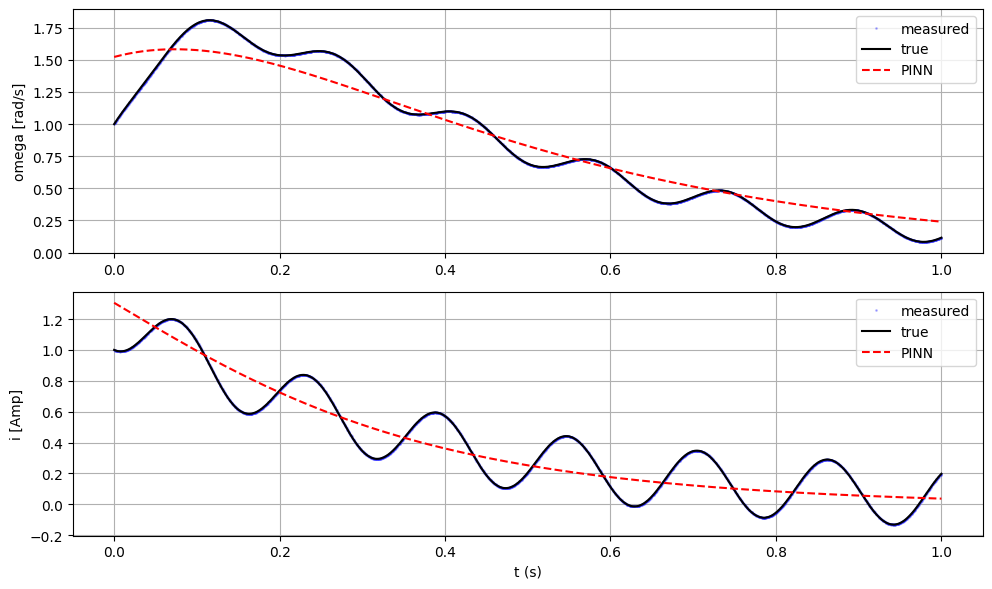

In [8]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, y_array[:, 0], 'b.', markersize=2, alpha=0.25, label='measured')
plt.plot(t, x_array[:, 0], 'k', linewidth=1.5, label='true')
plt.plot(t, x_pinn[:, 0], 'r--', linewidth=1.5, label='PINN')
plt.ylabel('omega [rad/s]')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, y_array[:, 1], 'b.', markersize=2, alpha=0.25, label='measured')
plt.plot(t, x_array[:, 1], 'k', linewidth=1.5, label='true')
plt.plot(t, x_pinn[:, 1], 'r--', linewidth=1.5, label='PINN')
plt.ylabel('i [Amp]')
plt.xlabel('t (s)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**Plot control input and the key coefficients**

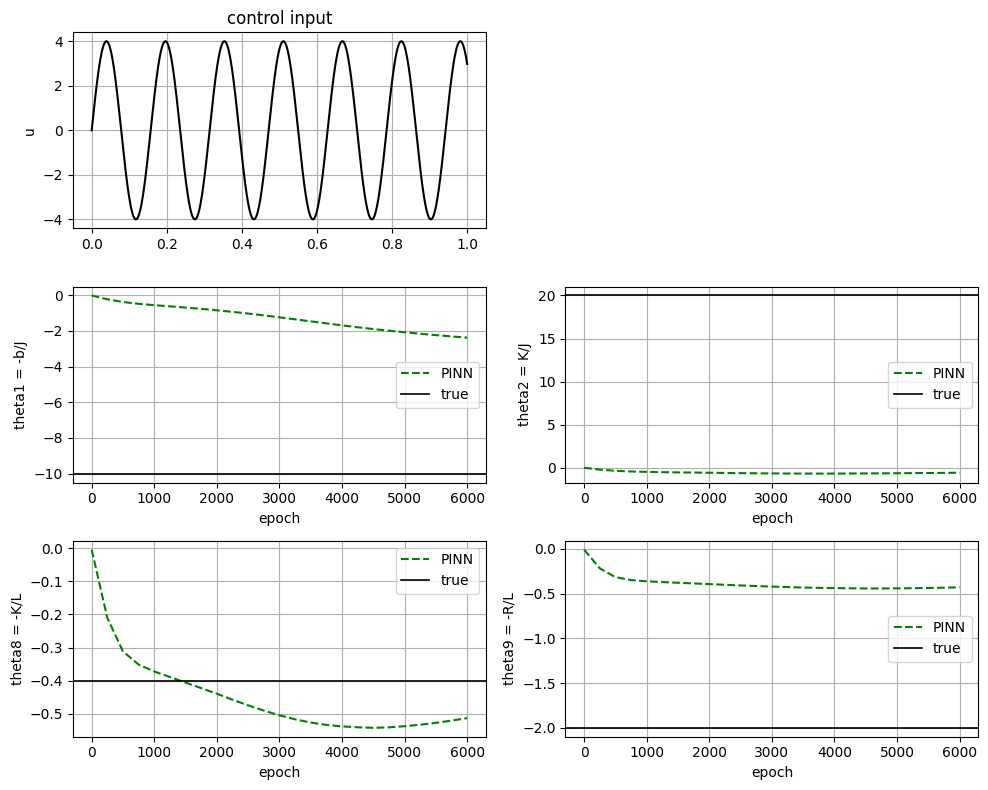

In [9]:
theta_hist = np.asarray(history['theta'])
epoch_hist = np.asarray(history['epoch'])

fig, axs = plt.subplots(3, 2, figsize=(10, 8))

axs[0, 0].plot(t, u_array[:, 0], 'k')
axs[0, 0].set_ylabel('u')
axs[0, 0].set_title('control input')
axs[0, 0].grid(True)

plots = [
    (1, 0, 0, 0, 'theta1 = -b/J'),
    (1, 1, 0, 1, 'theta2 = K/J'),
    (2, 0, 1, 0, 'theta8 = -K/L'),
    (2, 1, 1, 1, 'theta9 = -R/L'),
]

for row, col, eq_idx, coeff_idx, label in plots:
    axs[row, col].plot(epoch_hist, theta_hist[:, eq_idx, coeff_idx], 'g--', label='PINN')
    axs[row, col].axhline(true_coeff[eq_idx, coeff_idx], color='k', linewidth=1.2, label='true')
    axs[row, col].set_ylabel(label)
    axs[row, col].set_xlabel('epoch')
    axs[row, col].grid(True)
    axs[row, col].legend()

axs[0, 1].axis('off')
plt.tight_layout()
plt.show()


**Coefficient table in the original 14-term layout**

Rows correspond to the two state equations. Columns are
`omega`, `i`, `omega^2`, `i^2`, `omega*i`, `u`, `u^2`.


In [10]:
feature_names = ['omega', 'i', 'omega^2', 'i^2', 'omega*i', 'u', 'u^2']

print('Features:')
print(feature_names)
print('\nPINN coefficients:')
print(np.round(learned_coeff, 3))
print('\nTrue coefficients:')
print(true_coeff)


Features:
['omega', 'i', 'omega^2', 'i^2', 'omega*i', 'u', 'u^2']

PINN coefficients:
[[-2.383e+00 -5.810e-01 -2.350e-01  2.328e+00  1.353e+00 -0.000e+00
  -2.000e-03]
 [-5.130e-01 -4.290e-01 -4.470e-01 -1.200e-01 -3.130e-01  0.000e+00
   0.000e+00]]

True coefficients:
[[-10.   20.    0.    0.    0.    0.    0. ]
 [ -0.4  -2.    0.    0.    0.    2.    0. ]]
